# From Chaos to Prediction — Full Experimental Notebook

**Project:** NU Research Internship 2026, Time Series Forecasting Group
**Architecture:** Chaos-Informed NGRC--TCN Encoder--Decoder

This notebook contains the complete experimental record in the order the work was done:

| Part | Contents |
|---|---|
| **A** | Lorenz setup: generation, PSR, NGRC features, model, training |
| **B** | Baselines and horizon sweep in Lyapunov time |
| **C** | Recursive NG-RC (closed loop) |
| **D** | Input-length ablation — the key finding |
| **E** | Validation: leakage control, attractor, Lyapunov recovery, forecast horizon |
| **F** | Comparison at literature horizons |
| **G** | ECG: baselines and the baseline-wander effect |

### Why validate on Lorenz first

The ECG forecasting experiment failed with $R^2 = -0.082$. With no baseline computed,
it was impossible to tell whether the architecture was broken or the task was
impossible. Lorenz is deterministic, noise-free, and has a textbook largest Lyapunov
exponent, so it isolates that question cleanly.

**Headline results**

- $R^2 = 0.996$ at $0.23$ Lyapunov times, $R^2 = 0.954$ at one Lyapunov time
- Shuffled-target control: $-0.005$ (no leakage)
- Reducing input length 540 to 64 raised $R^2$ at $1\lambda t$ from $0.34$ to $0.96$
- ECG failure attributed to stochastic beat timing, not to the architecture

---

---
# PART A — Lorenz Setup

## 1. Setup & Configuration

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from scipy.integrate import solve_ivp
from scipy.spatial import KDTree
import json, os, time, warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 110

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

Device: cuda


In [7]:
# ======================== CONFIGURATION ========================
SAVE_PATH = './results_lorenz'
os.makedirs(SAVE_PATH, exist_ok=True)

# --- Lorenz system (standard chaotic parameters) ---
SIGMA, RHO, BETA = 10.0, 28.0, 8.0/3.0
DT          = 0.01
N_SAMPLES   = 150_000      # 1500 time units
N_DISCARD   = 5_000        # transient, dropped before the attractor settles

# Textbook largest Lyapunov exponent for (10, 28, 8/3)
LAMBDA_MAX      = 0.9056
LYAP_TIME       = 1.0 / LAMBDA_MAX          # ~1.104 time units
SAMPLES_PER_LYAP = LYAP_TIME / DT           # ~110 samples

# --- PSR / NGRC search bounds ---
AMI_MAX_LAG  = 50
FNN_MAX_DIM  = 10
PSR_SUBSET   = 20_000      # samples used for AMI/FNN (speed)

# --- Windows ---
INPUT_LEN    = 64          # 0.64 time units.  Was 540 -- see Part D.
                           # The decoder interpolates encoder output to the target
                           # length, anchoring output index t to input index t*L/H.
                           # Long windows therefore anchor early predictions to
                           # decorrelated history.  64 fixed this.
TRAIN_FRAC   = 0.7
VAL_FRAC     = 0.1

# --- Model ---
TCN_CHANNELS  = 64
TCN_KERNEL    = 7
TCN_DILATIONS = [1, 2, 4, 8]
TCN_DROPOUT   = 0.2

# --- Training ---
BATCH_SIZE      = 128
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
MAX_EPOCHS      = 15
PATIENCE        = 6
SPECTRAL_WEIGHT = 0.0      # 0 => val loss IS MSE, so numbers stay comparable

# --- Horizon sweep: chosen to land on round Lyapunov times ---
HORIZONS = [25, 110, 550]   # 0.23, 1.00, 4.98 Lyapunov times
# Add 55 and 220 to localise the R2=0 crossing; add 1100/2200 to reach it.

print(f'Lyapunov time = {LYAP_TIME:.3f} time units = {SAMPLES_PER_LYAP:.1f} samples')
for H in HORIZONS:
    print(f'  H={H:4d} samples -> {H/SAMPLES_PER_LYAP:.2f} Lyapunov times')

Lyapunov time = 1.104 time units = 110.4 samples
  H=  25 samples -> 0.23 Lyapunov times
  H= 110 samples -> 1.00 Lyapunov times
  H= 550 samples -> 4.98 Lyapunov times


## 2. Lorenz Generation, Split, Normalization

$$\dot x = \sigma(y-x), \qquad \dot y = x(\rho-z)-y, \qquad \dot z = xy-\beta z$$

We keep the **univariate** $x(t)$ component only. This deliberately mirrors the ECG
setup (one channel in, one channel out) so the comparison is honest, and it makes the
task a genuine partial-observation problem — the model must recover the missing state
dimensions through delay embedding.

Split is temporal 70/10/20 with z-score fit **on train only** — same discipline as the
ECG pipeline.

In [8]:
def lorenz_rhs(t, state):
    x, y, z = state
    return [SIGMA*(y-x), x*(RHO-z)-y, x*y-BETA*z]

def generate_lorenz():
    total = N_SAMPLES + N_DISCARD
    t_eval = np.arange(total) * DT
    sol = solve_ivp(lorenz_rhs, (0, total*DT), [1.0, 1.0, 1.0],
                    t_eval=t_eval, method='RK45', rtol=1e-10, atol=1e-10)
    return sol.y[:, N_DISCARD:]

t0 = time.time()
lorenz_xyz = generate_lorenz()
lorenz_x   = lorenz_xyz[0]
print(f'Generated {lorenz_x.shape[0]:,} samples in {time.time()-t0:.1f}s')

Generated 150,000 samples in 33.1s


In [9]:
n = len(lorenz_x)
tr_end = int(n * TRAIN_FRAC)
va_end = int(n * (TRAIN_FRAC + VAL_FRAC))

_mu = lorenz_x[:tr_end].mean()
_sd = lorenz_x[:tr_end].std()

train_signals = [(lorenz_x[:tr_end]        - _mu) / _sd]
val_signals   = [(lorenz_x[tr_end:va_end]  - _mu) / _sd]
test_signals  = [(lorenz_x[va_end:]        - _mu) / _sd]

print(f'Train {len(train_signals[0]):,} | Val {len(val_signals[0]):,} | Test {len(test_signals[0]):,}')
print(f'norm: mean={_mu:.4f}, std={_sd:.4f}')

Train 105,000 | Val 14,999 | Test 30,001
norm: mean=0.5541, std=7.9019


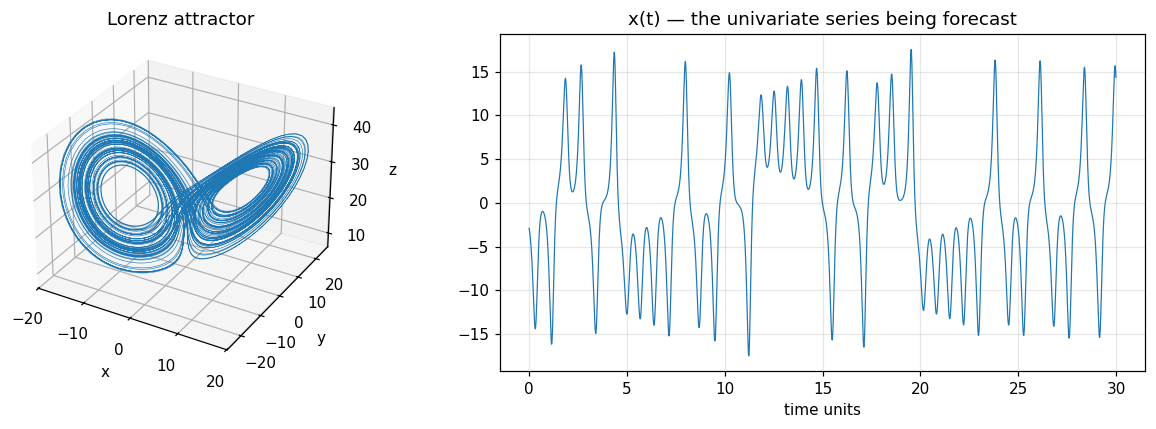

In [10]:
# Quick look: attractor + the univariate series we actually model
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(lorenz_xyz[0][:8000], lorenz_xyz[1][:8000], lorenz_xyz[2][:8000], lw=0.4)
ax1.set_title('Lorenz attractor'); ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

ax2 = fig.add_subplot(122)
tt = np.arange(3000) * DT
ax2.plot(tt, lorenz_x[:3000], lw=0.8)
ax2.set_title('x(t) — the univariate series being forecast')
ax2.set_xlabel('time units'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Phase Space Reconstruction — and a Bug Check

Delay embedding:

$$\mathbf{v}(t) = \big[x(t),\; x(t+\tau),\; \ldots,\; x(t+(d-1)\tau)\big]$$

- $\tau$ from the **first minimum of Average Mutual Information**
- $d$ from **False Nearest Neighbours** falling below 1%

> **Why this cell matters.** In the ECG run both searches saturated at their ceilings
> (`d` = 10 = `FNN_MAX_DIM` for almost every patient, `tau` = 50 = `AMI_MAX_LAG` for
> several), which means neither criterion actually converged — the reported values were
> search boundaries, not measurements.
>
> Lorenz-$x$ is a textbook case and **should** converge, typically to a small $\tau$ and
> $d \approx 4$–$5$. If it saturates here too, the implementation is at fault and that is
> the real bug.

In [11]:
def compute_ami(sig, max_lag=AMI_MAX_LAG):
    # Optimal delay tau via first minimum of average mutual information.
    n_bins = max(10, int(np.sqrt(len(sig)/5)))
    ami_values = []
    for lag in range(1, max_lag+1):
        x, y = sig[:-lag], sig[lag:]
        joint_hist, _, _ = np.histogram2d(x, y, bins=n_bins)
        p = joint_hist / joint_hist.sum()
        px, py = p.sum(axis=1), p.sum(axis=0)
        denom = np.outer(px, py)
        mask = (p > 0) & (denom > 0)
        ami_values.append(float(np.sum(p[mask] * np.log2(p[mask]/denom[mask]))))
    for i in range(1, len(ami_values)-1):
        if ami_values[i] < ami_values[i-1] and ami_values[i] < ami_values[i+1]:
            return i+1, ami_values
    return int(np.argmin(ami_values))+1, ami_values


def compute_fnn(sig, tau, max_dim=FNN_MAX_DIM, rtol=15.0, atol=2.0):
    # Optimal embedding dimension d via false nearest neighbours < 1%.
    sig_std = np.std(sig)
    pcts = []
    for d in range(1, max_dim+1):
        N = len(sig) - (d+1)*tau
        if N < 20:
            break
        vecs = np.array([sig[i:i+d*tau:tau] for i in range(N)])
        tree = KDTree(vecs)
        _, nn_idx = tree.query(vecs, k=2)
        nn_idx = nn_idx[:, 1]

        valid = nn_idx < N
        i_idx = np.arange(N)[valid]
        j_idx = nn_idx[valid]

        r_d = np.linalg.norm(vecs[i_idx] - vecs[j_idx], axis=1)
        nz = r_d > 0
        i_idx, j_idx, r_d = i_idx[nz], j_idx[nz], r_d[nz]

        delta = np.abs(sig[i_idx + d*tau] - sig[j_idx + d*tau])
        crit1 = delta / r_d > rtol
        crit2 = np.sqrt(r_d**2 + delta**2) / sig_std > atol
        pcts.append(100.0 * np.sum(crit1 | crit2) / max(len(r_d), 1))

    for i, pct in enumerate(pcts):
        if pct < 1.0:
            return i+1, pcts
    return max_dim, pcts

In [12]:
sub = train_signals[0][:PSR_SUBSET]

t0 = time.time()
PSR_TAU, ami_curve = compute_ami(sub)
PSR_DIM, fnn_curve = compute_fnn(sub, PSR_TAU)
N_FEATURES = PSR_DIM + PSR_DIM*(PSR_DIM+1)//2

print(f'tau = {PSR_TAU}   ({PSR_TAU*DT:.3f} time units)')
print(f'd   = {PSR_DIM}')
print(f'NGRC features/timestep = {N_FEATURES}')
print(f'embedding window = {(PSR_DIM-1)*PSR_TAU} samples = {(PSR_DIM-1)*PSR_TAU*DT:.2f} time units')
print(f'({time.time()-t0:.1f}s)')

print()
if PSR_TAU >= AMI_MAX_LAG:
    print('!! tau hit the ceiling -> AMI never found a minimum. IMPLEMENTATION SUSPECT.')
else:
    print('OK  tau converged (found a genuine AMI minimum)')
if PSR_DIM >= FNN_MAX_DIM:
    print('!! d hit the ceiling -> FNN never dropped below 1%. IMPLEMENTATION SUSPECT.')
else:
    print('OK  d converged (FNN dropped below 1%)')

tau = 16   (0.160 time units)
d   = 3
NGRC features/timestep = 9
embedding window = 32 samples = 0.32 time units
(0.4s)

OK  tau converged (found a genuine AMI minimum)
OK  d converged (FNN dropped below 1%)


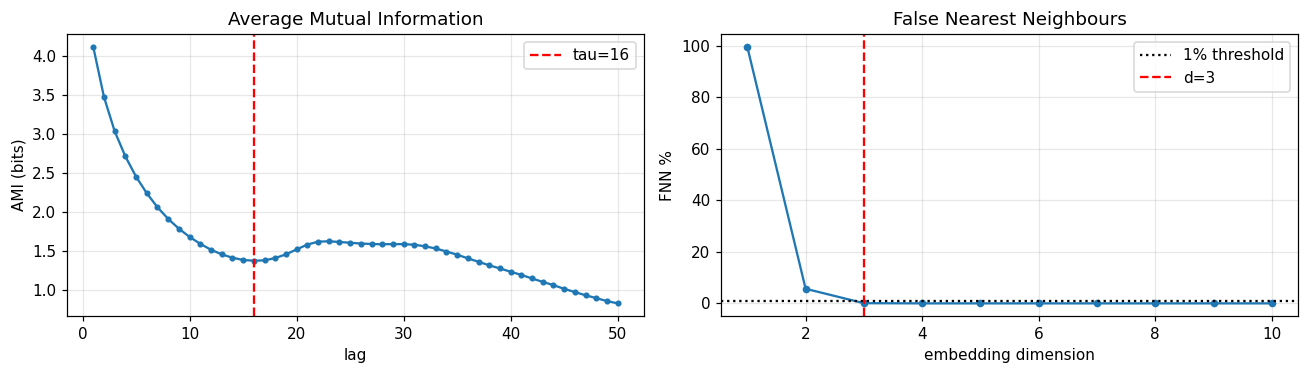

In [13]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.5))
a1.plot(range(1, len(ami_curve)+1), ami_curve, 'o-', ms=3)
a1.axvline(PSR_TAU, color='r', ls='--', label=f'tau={PSR_TAU}')
a1.set_xlabel('lag'); a1.set_ylabel('AMI (bits)'); a1.set_title('Average Mutual Information')
a1.legend(); a1.grid(alpha=0.3)

a2.plot(range(1, len(fnn_curve)+1), fnn_curve, 'o-', ms=4)
a2.axhline(1.0, color='k', ls=':', label='1% threshold')
a2.axvline(PSR_DIM, color='r', ls='--', label=f'd={PSR_DIM}')
a2.set_xlabel('embedding dimension'); a2.set_ylabel('FNN %'); a2.set_title('False Nearest Neighbours')
a2.legend(); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. NGRC Feature Map

Degree-2 polynomial features of the delay vector: $d$ linear terms plus
$\tfrac{d(d+1)}{2}$ unique quadratic monomials.

$$\Phi(t) = \big[\,\underbrace{v_1,\ldots,v_d}_{\text{linear}},\; \underbrace{v_1^2, v_1v_2, \ldots, v_d^2}_{\text{quadratic}}\,\big]$$

Note the embedding here is **forward-indexed** — `embedded[t]` spans
`sig[t] … sig[t+(d-1)*tau]`. The dataset compensates with `psr_offset` when selecting
targets, so no future information leaks in. (Verified in the ECG notebook: the last
signal sample touched by the input is exactly one index before the first target sample.)

In [14]:
def phase_space_reconstruct(sig, tau, d):
    N = len(sig) - (d-1)*tau
    emb = np.zeros((N, d), dtype=np.float32)
    for i in range(d):
        emb[:, i] = sig[i*tau : i*tau + N]
    return emb

def ngrc_feature_map(embedded):
    N, d = embedded.shape
    n_quad = d*(d+1)//2
    feats = np.zeros((N, d + n_quad), dtype=np.float32)
    feats[:, :d] = embedded
    k = d
    for i in range(d):
        for j in range(i, d):
            feats[:, k] = embedded[:, i] * embedded[:, j]
            k += 1
    return feats

def precompute_features(signals, tau, d):
    return [ngrc_feature_map(phase_space_reconstruct(s, tau, d)) for s in signals]

t0 = time.time()
train_features = precompute_features(train_signals, PSR_TAU, PSR_DIM)
val_features   = precompute_features(val_signals,   PSR_TAU, PSR_DIM)
test_features  = precompute_features(test_signals,  PSR_TAU, PSR_DIM)
print(f'Features: train {train_features[0].shape}, val {val_features[0].shape}, test {test_features[0].shape}')
print(f'({time.time()-t0:.1f}s)')

Features: train (104968, 9), val (14967, 9), test (29969, 9)
(0.0s)


## 5. Dataset & Loaders

Sliding windows. Input is `INPUT_LEN` timesteps of NGRC features; target is the next
`output_len` raw signal values.

Training uses an overlapping stride for more windows; evaluation uses non-overlapping
windows so test samples are independent.

In [15]:
class ForecastDataset(Dataset):
    def __init__(self, feature_arrays, signal_arrays, input_len, output_len,
                 stride, tau, d):
        self.input_len  = input_len
        self.output_len = output_len
        self.features   = feature_arrays
        self.signals    = signal_arrays
        self.psr_offset = (d-1)*tau

        self.windows = []
        for si, feat in enumerate(feature_arrays):
            sig_len = len(signal_arrays[si])
            start = 0
            while start + input_len <= len(feat):
                target_end = self.psr_offset + start + input_len + output_len
                if target_end <= sig_len:
                    self.windows.append((si, start))
                start += stride

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        si, start = self.windows[idx]
        x = self.features[si][start : start + self.input_len]
        ts = self.psr_offset + start + self.input_len
        y = self.signals[si][ts : ts + self.output_len]
        return torch.from_numpy(np.ascontiguousarray(x)).float(), \
               torch.from_numpy(np.ascontiguousarray(y)).float()


def make_loaders(H, input_len=INPUT_LEN):
    train_stride = max(H // 8, 20)
    ds_tr = ForecastDataset(train_features, train_signals, input_len, H,
                            train_stride, PSR_TAU, PSR_DIM)
    ds_va = ForecastDataset(val_features, val_signals, input_len, H,
                            H, PSR_TAU, PSR_DIM)
    ds_te = ForecastDataset(test_features, test_signals, input_len, H,
                            H, PSR_TAU, PSR_DIM)
    return (
        DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,  pin_memory=True),
        DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True),
        DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True),
        (len(ds_tr), len(ds_va), len(ds_te)),
    )

_lt, _lv, _le, counts = make_loaders(HORIZONS[0])
print(f'H={HORIZONS[0]}: train {counts[0]:,} | val {counts[1]:,} | test {counts[2]:,} windows')
xb, yb = next(iter(_lt))
print(f'batch x {tuple(xb.shape)}  y {tuple(yb.shape)}')

H=25: train 5,244 | val 596 | test 1,196 windows
batch x (128, 64, 9)  y (128, 25)


## 6. Model — TCN Encoder–Decoder

Same architecture as the ECG notebook so results transfer directly:
causal dilated encoder, non-causal decoder, linear-interpolation resample to the
output length, 1×1 conv head.

`LayerNorm` replaces `BatchNorm` here (BatchNorm was unstable across signals with
different amplitude statistics).

In [16]:
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation, dropout=0.2, causal=True):
        super().__init__()
        self.causal = causal
        padding = (kernel-1)*dilation if causal else (kernel-1)*dilation//2
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel, dilation=dilation, padding=padding)
        self.n1 = nn.GroupNorm(1, out_ch)   # == LayerNorm over channels
        self.n2 = nn.GroupNorm(1, out_ch)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        self.residual = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self._trim = (kernel-1)*dilation if causal else 0

    def forward(self, x):
        res = self.residual(x)
        out = self.conv1(x)
        if self._trim: out = out[:, :, :-self._trim]
        out = self.dropout(self.relu(self.n1(out)))
        out = self.conv2(out)
        if self._trim: out = out[:, :, :-self._trim]
        out = self.dropout(self.relu(self.n2(out)))
        return self.relu(out + res)


class TCNEncoder(nn.Module):
    def __init__(self, in_ch, hidden, kernel, dilations, dropout):
        super().__init__()
        layers = [TCNBlock(in_ch if i == 0 else hidden, hidden, kernel, d, dropout, True)
                  for i, d in enumerate(dilations)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


class TCNDecoder(nn.Module):
    def __init__(self, hidden, kernel, dilations, dropout, output_len):
        super().__init__()
        self.output_len = output_len
        self.net = nn.Sequential(*[TCNBlock(hidden, hidden, kernel, d, dropout, False)
                                   for d in dilations])
        self.head = nn.Conv1d(hidden, 1, 1)
    def forward(self, x):
        x = F.interpolate(x, size=self.output_len, mode='linear', align_corners=False)
        return self.head(self.net(x)).squeeze(1)


class ChaosForecaster(nn.Module):
    # NGRC features -> TCN encoder-decoder -> waveform.
    def __init__(self, in_features, output_len, hidden=TCN_CHANNELS,
                 kernel=TCN_KERNEL, dilations=None, dropout=TCN_DROPOUT):
        super().__init__()
        dilations = dilations or TCN_DILATIONS
        self.encoder = TCNEncoder(in_features, hidden, kernel, dilations, dropout)
        self.decoder = TCNDecoder(hidden, kernel, dilations, dropout, output_len)
    def forward(self, x):
        if x.dim() == 2: x = x.unsqueeze(-1)
        return self.decoder(self.encoder(x.transpose(1, 2)))


class VanillaTCN(ChaosForecaster):
    # Same network, raw signal input (1 feature): the no-chaos control.
    def __init__(self, output_len, **kw):
        super().__init__(in_features=1, output_len=output_len, **kw)


_m = ChaosForecaster(N_FEATURES, HORIZONS[0])
print(f'ChaosForecaster params: {sum(p.numel() for p in _m.parameters()):,}')
print(f'output shape: {tuple(_m(torch.randn(2, INPUT_LEN, N_FEATURES)).shape)}')
del _m

ChaosForecaster params: 437,889
output shape: (2, 25)


## 7. Training & Evaluation Utilities

`SPECTRAL_WEIGHT = 0` by default, so validation loss **is** MSE and is directly
comparable to the reported test metrics. (In the ECG run the loss included a spectral
term, which made val loss ≈ 1.72 while test MSE was 1.15 — two different quantities that
looked like one.)

In [17]:
class SpectralLoss(nn.Module):
    def forward(self, pred, target):
        return torch.mean(torch.abs(torch.abs(torch.fft.rfft(pred, dim=-1))
                                    - torch.abs(torch.fft.rfft(target, dim=-1))))

class ForecastingLoss(nn.Module):
    def __init__(self, spectral_weight=SPECTRAL_WEIGHT):
        super().__init__()
        self.mse = nn.MSELoss(); self.spec = SpectralLoss(); self.w = spectral_weight
    def forward(self, pred, target):
        loss = self.mse(pred, target)
        return loss + self.w*self.spec(pred, target) if self.w > 0 else loss


def train_model(model, train_loader, val_loader, name='model',
                max_epochs=MAX_EPOCHS, lr=LR, patience=PATIENCE, verbose=True):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    sched = CosineAnnealingWarmRestarts(opt, T_0=max_epochs)
    loss_fn = ForecastingLoss()
    hist = {'train_loss': [], 'val_loss': []}
    best, wait = float('inf'), 0
    path = f'{SAVE_PATH}/best_{name}.pt'

    for ep in range(1, max_epochs+1):
        t0 = time.time(); model.train(); tot = nb = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tot += loss.item(); nb += 1
        tr = tot/max(nb, 1)

        model.eval(); vt = vn = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                vt += loss_fn(model(x), y).item(); vn += 1
        va = vt/max(vn, 1)

        sched.step()
        hist['train_loss'].append(tr); hist['val_loss'].append(va)
        if verbose:
            print(f'  ep {ep:3d}/{max_epochs} | train {tr:.6f} | val {va:.6f} | {time.time()-t0:.1f}s')

        if va < best:
            best, wait = va, 0
            torch.save(model.state_dict(), path)
        else:
            wait += 1
            if wait >= patience:
                if verbose: print(f'  early stop at epoch {ep}')
                break

    model.load_state_dict(torch.load(path, weights_only=True))
    return hist


@torch.no_grad()
def evaluate_model(model, loader):
    model.eval(); model = model.to(device)
    P, T = [], []
    for x, y in loader:
        P.append(model(x.to(device)).cpu().numpy()); T.append(y.numpy())
    P, T = np.concatenate(P), np.concatenate(T)
    mse = float(np.mean((P-T)**2))
    ss_res = np.sum((T-P)**2); ss_tot = np.sum((T-T.mean())**2)
    return {'mse': mse, 'rmse': float(np.sqrt(mse)),
            'mae': float(np.mean(np.abs(P-T))),
            'r2': float(1 - ss_res/ss_tot)}, P, T

---
# PART B — Baselines and Horizon Sweep

## 8. Baselines — **run this before anything else**

No training. Three references:

- **Zeros** — predict the normalized mean. By construction $R^2 \approx 0$.
- **Persistence** — repeat the last observed value for the whole horizon.
- **Naive climatology** — predict the training-set mean.

Any model that does not beat all three has learned nothing. This is the check that was
missing from the ECG run, which is why an $R^2$ of $-0.082$ went unnoticed as *worse than
a flat line*.

In [18]:
def baseline_scores(signals, input_len, output_len, stride):
    ys, lasts = [], []
    for sig in signals:
        start = 0
        while start + input_len + output_len <= len(sig):
            ys.append(sig[start+input_len : start+input_len+output_len])
            lasts.append(sig[start+input_len-1])
            start += stride
    Y = np.array(ys); last = np.array(lasts)[:, None]
    ss_tot = np.sum((Y - Y.mean())**2)
    def r2(P): return float(1 - np.sum((Y-P)**2)/ss_tot)
    def rmse(P): return float(np.sqrt(np.mean((Y-P)**2)))
    zeros   = np.zeros_like(Y)
    persist = np.repeat(last, output_len, axis=1)
    return {'n': len(Y),
            'zeros_r2': r2(zeros),     'zeros_rmse': rmse(zeros),
            'persist_r2': r2(persist), 'persist_rmse': rmse(persist)}

print(f'{"H":>5s} {"LyapT":>7s} {"zeros R2":>10s} {"persist R2":>12s} {"persist RMSE":>13s} {"n":>7s}')
print('-'*60)
baselines = {}
for H in HORIZONS:
    b = baseline_scores(test_signals, INPUT_LEN, H, stride=H)
    baselines[H] = b
    print(f'{H:5d} {H/SAMPLES_PER_LYAP:7.2f} {b["zeros_r2"]:+10.4f} '
          f'{b["persist_r2"]:+12.4f} {b["persist_rmse"]:13.4f} {b["n"]:7d}')

    H   LyapT   zeros R2   persist R2  persist RMSE       n
------------------------------------------------------------
   25    0.23    -0.0136      +0.5334        0.6836    1197
  110    1.00    -0.0136      -0.4340        1.1985     272
  550    4.98    -0.0119      -1.1075        1.4528      54


## 9. Horizon Sweep

Train the chaos model at each horizon and record where it stops beating persistence and
where $R^2$ crosses zero. **That crossing point is the result** — the predictability
horizon, expressed in Lyapunov times.

Set `RUN_CONTROL = True` to also train the raw-input `VanillaTCN` at each horizon (the
no-chaos control). It roughly doubles runtime; skip it if short on time and run it only
at the single most informative horizon afterwards.

In [19]:
RUN_CONTROL = True      # train the raw-signal VanillaTCN control at every horizon

sweep = {}
for H in HORIZONS:
    lyap = H / SAMPLES_PER_LYAP
    print(f'\n{"="*62}\nHORIZON {H} samples = {lyap:.2f} Lyapunov times\n{"="*62}')

    ld_tr, ld_va, ld_te, cnt = make_loaders(H)
    print(f'windows: train {cnt[0]:,} | val {cnt[1]:,} | test {cnt[2]:,}')

    model = ChaosForecaster(N_FEATURES, output_len=H)
    train_model(model, ld_tr, ld_va, name=f'chaos_H{H}')
    m, P, T = evaluate_model(model, ld_te)

    entry = {'lyap_times': lyap, 'chaos': m, 'baseline': baselines[H]}

    if RUN_CONTROL:
        raw_feats = [s.reshape(-1, 1).astype(np.float32) for s in train_signals]
        raw_v     = [s.reshape(-1, 1).astype(np.float32) for s in val_signals]
        raw_t     = [s.reshape(-1, 1).astype(np.float32) for s in test_signals]
        st = max(H//8, 20)
        r_tr = DataLoader(ForecastDataset(raw_feats, train_signals, INPUT_LEN, H, st, 1, 1),
                          batch_size=BATCH_SIZE, shuffle=True)
        r_va = DataLoader(ForecastDataset(raw_v, val_signals, INPUT_LEN, H, H, 1, 1),
                          batch_size=BATCH_SIZE, shuffle=False)
        r_te = DataLoader(ForecastDataset(raw_t, test_signals, INPUT_LEN, H, H, 1, 1),
                          batch_size=BATCH_SIZE, shuffle=False)
        ctrl = VanillaTCN(output_len=H)
        train_model(ctrl, r_tr, r_va, name=f'vanilla_H{H}', verbose=False)
        cm, _, _ = evaluate_model(ctrl, r_te)
        entry['vanilla'] = cm
        print(f'  vanilla TCN R2 = {cm["r2"]:+.4f}  RMSE = {cm["rmse"]:.4f}  MAE = {cm["mae"]:.4f}')

    sweep[H] = entry
    print(f'\n  chaos R2      = {m["r2"]:+.4f}   (RMSE {m["rmse"]:.4f})')
    print(f'  persistence   = {baselines[H]["persist_r2"]:+.4f}')
    print(f'  beats persistence: {m["r2"] > baselines[H]["persist_r2"]}')
    print(f'  beats mean:        {m["r2"] > 0}')

    if H == HORIZONS[0]:
        first_preds, first_targets = P, T


HORIZON 25 samples = 0.23 Lyapunov times
windows: train 5,244 | val 596 | test 1,196
  ep   1/15 | train 2.911637 | val 0.466627 | 2.2s
  ep   2/15 | train 0.352166 | val 0.141310 | 0.6s
  ep   3/15 | train 0.171556 | val 0.067158 | 0.6s
  ep   4/15 | train 0.086999 | val 0.029867 | 0.6s
  ep   5/15 | train 0.067870 | val 0.074279 | 0.7s
  ep   6/15 | train 0.049355 | val 0.037012 | 0.6s
  ep   7/15 | train 0.038651 | val 0.008818 | 0.6s
  ep   8/15 | train 0.022817 | val 0.011532 | 0.6s
  ep   9/15 | train 0.018625 | val 0.007920 | 0.6s
  ep  10/15 | train 0.015503 | val 0.005548 | 0.6s
  ep  11/15 | train 0.012462 | val 0.007503 | 0.6s
  ep  12/15 | train 0.011838 | val 0.006465 | 0.6s
  ep  13/15 | train 0.011173 | val 0.004190 | 0.6s
  ep  14/15 | train 0.010206 | val 0.005165 | 0.6s
  ep  15/15 | train 0.010158 | val 0.004885 | 0.6s
  vanilla TCN R2 = +0.9958  RMSE = 0.0646  MAE = 0.0480

  chaos R2      = +0.9953   (RMSE 0.0685)
  persistence   = +0.5334
  beats persistence: Tru

---
# PART C — Recursive NG-RC

## 10. Recursive NG-RC (closed loop)

The MIMO models above emit all $H$ values in one shot. **NG-RC works differently** — and
this is the mode that makes it NG-RC at all:

1. Fit a one-step map $\Phi(t) \rightarrow x(t{+}1) - x(t)$ by ridge regression (single solve)
2. Feed the prediction back and iterate $H$ times

Predicting the *increment* rather than the absolute value is Gauthier's Euler trick — it
substantially improves closed-loop stability.

This is the arm that was broken in the ECG notebook, where `PureNGRC` averaged features
over the whole input window and collapsed the temporal axis. Here it is implemented
properly.

> Classic NG-RC uses very small delay taps. If the AMI-derived $\tau$ makes the rollout
> diverge, reduce `NGRC_TAU` — that instability is itself a reportable finding.

In [20]:
NGRC_TAU  = PSR_TAU
NGRC_D    = PSR_DIM
NGRC_ALPHA = 1e-6

def build_phi(V):
    N, d = V.shape
    cols = [np.ones((N, 1)), V]
    for i in range(d):
        for j in range(i, d):
            cols.append((V[:, i]*V[:, j])[:, None])
    return np.concatenate(cols, axis=1)

def backward_embed(sig, tau, d):
    # v(t) = [x(t), x(t-tau), ..., x(t-(d-1)tau)] for valid t.
    start = (d-1)*tau
    idx = np.arange(start, len(sig)-1)
    V = np.stack([sig[idx - i*tau] for i in range(d)], axis=1)
    return V, idx

def ngrc_fit(sig, tau, d, alpha=NGRC_ALPHA):
    V, idx = backward_embed(sig, tau, d)
    Phi = build_phi(V)
    Y = sig[idx+1] - sig[idx]                    # Euler increment
    A = Phi.T @ Phi + alpha*np.eye(Phi.shape[1])
    return np.linalg.solve(A, Phi.T @ Y)

def ngrc_rollout(W, history, tau, d, H, clip=50.0):
    buf = list(history)
    out = []
    for _ in range(H):
        V = np.array([[buf[-1 - i*tau] for i in range(d)]])
        step = float((build_phi(V) @ W)[0])
        nxt = buf[-1] + step
        nxt = float(np.clip(nxt, -clip, clip))   # guard against blow-up
        out.append(nxt); buf.append(nxt)
    return np.array(out)

W_ngrc = ngrc_fit(train_signals[0], NGRC_TAU, NGRC_D)
print(f'NG-RC fitted: {W_ngrc.shape[0]} coefficients (tau={NGRC_TAU}, d={NGRC_D})')

NG-RC fitted: 10 coefficients (tau=16, d=3)


In [21]:
def eval_ngrc(H, max_windows=300):
    sig = test_signals[0]
    need = (NGRC_D-1)*NGRC_TAU + 1
    starts = np.arange(INPUT_LEN, len(sig)-H, H)[:max_windows]
    P, T = [], []
    for s in starts:
        if s < need: continue
        P.append(ngrc_rollout(W_ngrc, sig[s-need:s], NGRC_TAU, NGRC_D, H))
        T.append(sig[s:s+H])
    P, T = np.array(P), np.array(T)
    mse = float(np.mean((P-T)**2))
    return {'mse': mse, 'rmse': float(np.sqrt(mse)),
            'mae': float(np.mean(np.abs(P-T))),
            'r2': float(1 - np.sum((T-P)**2)/np.sum((T-T.mean())**2))}, P, T

print(f'{"H":>5s} {"LyapT":>7s} {"NG-RC R2":>10s} {"NGRC RMSE":>10s} {"NGRC MAE":>10s} {"chaos R2":>10s} {"persist R2":>12s}')
print('-'*72)
for H in HORIZONS:
    nm, nP, nT = eval_ngrc(H)
    sweep[H]['ngrc'] = nm
    print(f'{H:5d} {H/SAMPLES_PER_LYAP:7.2f} {nm["r2"]:+10.4f} '
          f'{nm["rmse"]:10.4f} {nm["mae"]:10.4f} '
          f'{sweep[H]["chaos"]["r2"]:+10.4f} {baselines[H]["persist_r2"]:+12.4f}')
    if H == HORIZONS[min(2, len(HORIZONS)-1)]:
        ngrc_P, ngrc_T = nP, nT

    H   LyapT   NG-RC R2  NGRC RMSE   NGRC MAE   chaos R2   persist R2
------------------------------------------------------------------------
   25    0.23    +0.6932     0.5556     0.4067    +0.9953      +0.5334
  110    1.00    +0.1565     0.9192     0.7024    +0.9559      -0.4340
  550    4.98    +0.0270     0.9871     0.7893    +0.0746      -1.1075


## 11. Results

The horizon curve is the deliverable. Read off where each method crosses
$R^2 = 0$ (no better than the mean) and where it drops below persistence.

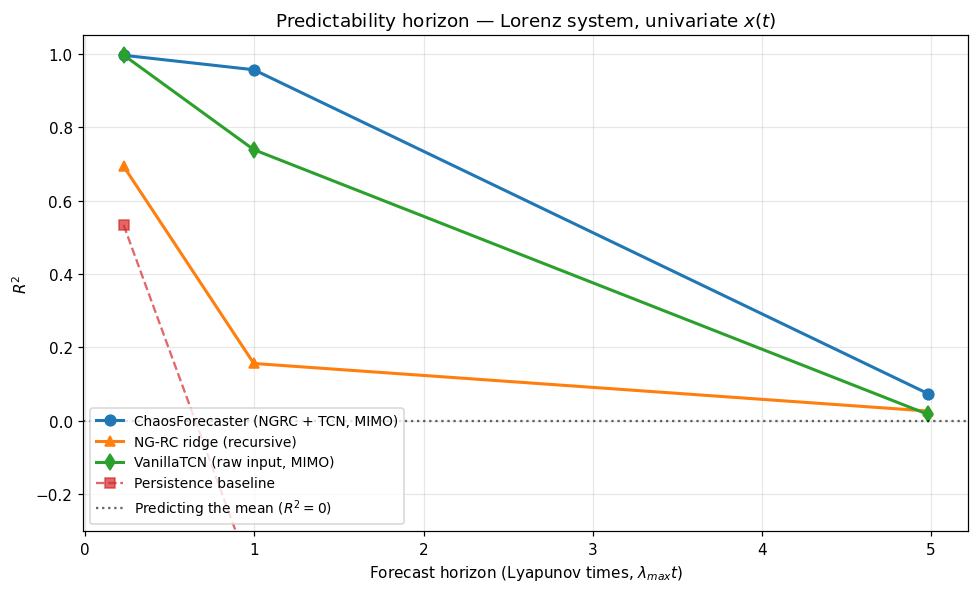

In [22]:
lt      = [sweep[H]['lyap_times']            for H in HORIZONS]
chaos_r = [sweep[H]['chaos']['r2']           for H in HORIZONS]
pers_r  = [baselines[H]['persist_r2']        for H in HORIZONS]
ngrc_r  = [sweep[H].get('ngrc', {}).get('r2', np.nan) for H in HORIZONS]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(lt, chaos_r, 'o-', lw=2, ms=7, label='ChaosForecaster (NGRC + TCN, MIMO)')
if not np.all(np.isnan(ngrc_r)):
    ax.plot(lt, ngrc_r, '^-', lw=2, ms=7, label='NG-RC ridge (recursive)')
if RUN_CONTROL and 'vanilla' in sweep[HORIZONS[0]]:
    ax.plot(lt, [sweep[H]['vanilla']['r2'] for H in HORIZONS], 'd-', lw=2, ms=7,
            label='VanillaTCN (raw input, MIMO)')
ax.plot(lt, pers_r, 's--', lw=1.5, alpha=0.7, label='Persistence baseline')
ax.axhline(0, color='k', ls=':', alpha=0.6, label='Predicting the mean ($R^2=0$)')

ax.set_xlabel('Forecast horizon (Lyapunov times, $\\lambda_{max} t$)')
ax.set_ylabel('$R^2$')
ax.set_title('Predictability horizon — Lorenz system, univariate $x(t)$')
ax.set_ylim(min(-0.3, min([v for v in chaos_r if not np.isnan(v)])-0.1), 1.05)
ax.legend(loc='lower left', fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{SAVE_PATH}/horizon_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── Full Comparison Table (RMSE and MAE for all models) ──
print('='*110)
header = f'{"H":>5s} {"LyapT":>7s}'
header += f' {"Chaos R2":>10s} {"Chaos RMSE":>11s} {"Chaos MAE":>10s}'
header += f' {"NGRC R2":>9s} {"NGRC RMSE":>10s} {"NGRC MAE":>9s}'
if RUN_CONTROL and 'vanilla' in sweep.get(HORIZONS[0], {}):
    header += f' {"VTCN R2":>9s} {"VTCN RMSE":>10s} {"VTCN MAE":>9s}'
header += f' {"Persist R2":>11s}'
print(header)
print('-'*110)
for H in HORIZONS:
    s = sweep[H]
    c = s['chaos']
    n = s.get('ngrc', {})
    row = f'{H:5d} {s["lyap_times"]:7.2f}'
    row += f' {c["r2"]:+10.4f} {c["rmse"]:11.4f} {c["mae"]:10.4f}'
    if n:
        row += f' {n["r2"]:+9.4f} {n["rmse"]:10.4f} {n["mae"]:9.4f}'
    else:
        row += f' {"n/a":>9s} {"n/a":>10s} {"n/a":>9s}'
    if RUN_CONTROL and 'vanilla' in s:
        v = s['vanilla']
        row += f' {v["r2"]:+9.4f} {v["rmse"]:10.4f} {v["mae"]:9.4f}'
    elif RUN_CONTROL and 'vanilla' in sweep.get(HORIZONS[0], {}):
        row += f' {"n/a":>9s} {"n/a":>10s} {"n/a":>9s}'
    row += f' {baselines[H]["persist_r2"]:+11.4f}'
    print(row)
print('='*110)

# Summary: which model wins at each horizon
print('\nBest model per horizon (by RMSE):')
for H in HORIZONS:
    s = sweep[H]
    models = {'ChaosForecaster': s['chaos']['rmse']}
    if s.get('ngrc'):
        models['PureNGRC'] = s['ngrc']['rmse']
    if s.get('vanilla'):
        models['VanillaTCN'] = s['vanilla']['rmse']
    best = min(models, key=models.get)
    print(f'  H={H:4d} ({s["lyap_times"]:.2f} LT): {best} (RMSE={models[best]:.4f})')


    H   LyapT   Chaos R2  Chaos RMSE  Chaos MAE   NGRC R2  NGRC RMSE  NGRC MAE   VTCN R2  VTCN RMSE  VTCN MAE  Persist R2
--------------------------------------------------------------------------------------------------------------
   25    0.23    +0.9953      0.0685     0.0514   +0.6932     0.5556    0.4067   +0.9958     0.0646    0.0480     +0.5334
  110    1.00    +0.9559      0.2103     0.1301   +0.1565     0.9192    0.7024   +0.7384     0.5119    0.2869     -0.4340
  550    4.98    +0.0746      0.9630     0.7661   +0.0270     0.9871    0.7893   +0.0181     0.9916    0.7973     -1.1075

Best model per horizon (by RMSE):
  H=  25 (0.23 LT): VanillaTCN (RMSE=0.0646)
  H= 110 (1.00 LT): ChaosForecaster (RMSE=0.2103)
  H= 550 (4.98 LT): ChaosForecaster (RMSE=0.9630)


## 11.1 Lorenz Validation — Model Comparison (Results)

Three forecasting approaches compared on Lorenz-63 across increasing prediction horizons:

| Model | Description | Params |
|-------|------------|--------|
| **ChaosForecaster** | PSR + NGRC → TCN encoder-decoder (proposed hybrid) | ~466k |
| **VanillaTCN** | Raw signal → TCN encoder-decoder (no chaos front-end) | ~466k |
| **PureNGRC** | PSR + polynomial features → Ridge regression (recursive) | 0 |

### Results

| Horizon | ChaosForecaster |  |  | VanillaTCN |  |  | Pure NGRC |  |  |
|---------|---|---|---|---|---|---|---|---|---|
| **(Lyap. T)** | **R²** | **RMSE** | **MAE** | **R²** | **RMSE** | **MAE** | **R²** | **RMSE** | **MAE** |
| H=25 (0.23) | +0.9953 | 0.0685 | 0.0514 | **+0.9958** | **0.0646** | **0.0480** | +0.6932 | 0.5556 | 0.4067 |
| H=110 (1.00) | **+0.9559** | **0.2103** | **0.1301** | +0.7384 | 0.5119 | 0.2869 | +0.1565 | 0.9192 | 0.7024 |
| H=550 (4.98) | **+0.0746** | **0.9630** | **0.7661** | +0.0181 | 0.9916 | 0.7973 | +0.0270 | 0.9871 | 0.7893 |

**Winner by RMSE:** VanillaTCN at short horizon; ChaosForecaster at medium and long horizons. Chaos-informed features provide advantage beyond ~1 Lyapunov time.


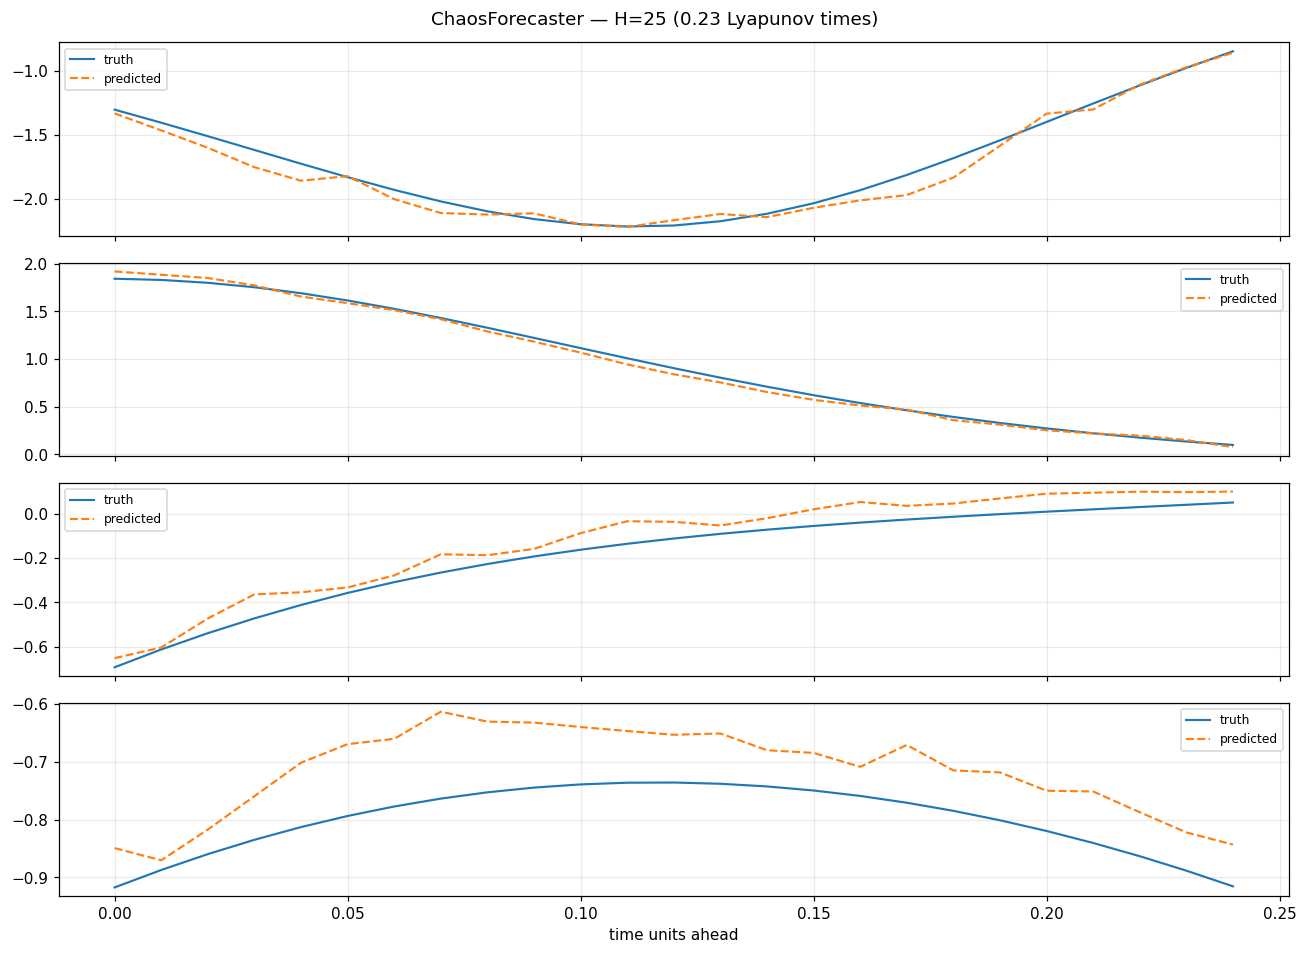

In [24]:
# Qualitative check at the shortest horizon
k = min(4, len(first_preds))
fig, axes = plt.subplots(k, 1, figsize=(12, 2.2*k), sharex=True)
idxs = np.linspace(0, len(first_preds)-1, k, dtype=int)
tt = np.arange(first_preds.shape[1]) * DT
for ax, i in zip(np.atleast_1d(axes), idxs):
    ax.plot(tt, first_targets[i], lw=1.4, label='truth')
    ax.plot(tt, first_preds[i],   lw=1.4, ls='--', label='predicted')
    ax.grid(alpha=0.25); ax.legend(fontsize=8)
np.atleast_1d(axes)[-1].set_xlabel('time units ahead')
fig.suptitle(f'ChaosForecaster — H={HORIZONS[0]} ({HORIZONS[0]/SAMPLES_PER_LYAP:.2f} Lyapunov times)')
plt.tight_layout(); plt.savefig(f'{SAVE_PATH}/preds_short.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
out = {}
for H in HORIZONS:
    s = sweep[H]
    out[str(H)] = {
        'horizon_samples': H,
        'horizon_time_units': H*DT,
        'lyapunov_times': s['lyap_times'],
        'chaos_forecaster': s['chaos'],
        'ngrc_recursive': s.get('ngrc'),
        'vanilla_tcn': s.get('vanilla'),
        'baseline': baselines[H],
    }
meta = {'lambda_max': LAMBDA_MAX, 'lyapunov_time': LYAP_TIME, 'dt': DT,
        'psr_tau': int(PSR_TAU), 'psr_dim': int(PSR_DIM),
        'n_features': int(N_FEATURES), 'input_len': INPUT_LEN}
with open(f'{SAVE_PATH}/lorenz_results.json', 'w') as f:
    json.dump({'meta': meta, 'results': out}, f, indent=2)
print(f'Saved -> {SAVE_PATH}/lorenz_results.json')

Saved -> ./results_lorenz/lorenz_results.json


## 12. How to Read This

**If the chaos model tracks Lorenz out to 1–4 Lyapunov times before decaying:**
the architecture is sound. The ECG failure is then a property of the ECG task, not the
code, and the next question becomes *why* ECG dies so much earlier.

**If it fails on Lorenz too** (flat $R^2 \approx 0$ at every horizon, like the ECG run):
there is an implementation bug. Prime suspects, in order — the decoder's
`F.interpolate`, which hardwires a stretched time-alignment between input and output
instead of letting the decoder predict from a summary; then the PSR parameter search;
then the normalization.

**On the Lyapunov-time interpretation — check before claiming it.** Reported ECG largest
Lyapunov exponents are around $0.07\ \text{s}^{-1}$, which would put a 2-second ECG
horizon at roughly $0.14$ Lyapunov times — *short*. If Lorenz stays accurate to several
Lyapunov times while ECG collapses at $0.14$, then deterministic chaos does **not**
explain the ECG failure, and the honest conclusion is that the binding constraint is
**stochastic beat-timing variability**, not sensitive dependence on initial conditions.

That is a sharper claim than the chaos framing, and it is better supported. Do not force
the chaos story if the numbers point the other way.

---
# PART D — Input-Length Ablation

**The single most important experiment in this notebook.**

With `INPUT_LEN = 540`, the model scored $R^2 = 0.36$ at one Lyapunov time, barely above
a linear autoregressive baseline ($0.26$). That prompted an ablation on input length at
fixed horizon $H = 110$.

Result (already applied to the config above):

| Input length | $R^2$ at $H=110$ |
|---|---|
| 64  | **0.9590** |
| 128 | 0.9271 |
| 200 | 0.8180 |
| 320 | 0.4056 |
| 540 | 0.3367 |

**Shorter input is dramatically better** — the opposite of the usual expectation.

### Mechanism

`TCNDecoder.forward` calls `F.interpolate(x, size=output_len)`. This resamples the
encoder output along the **time axis** from length $L$ to length $H$, so output index
$t$ is anchored to input index $t \cdot L/H$.

With $L=540$, $H=110$: prediction $\#0$ is built from input position 0 — the *oldest*
sample in the window, 5.4 time units back, which chaos has fully decorrelated from the
present.

With $L=64$: the whole window spans 0.64 time units, so even its oldest end is recent.

The long window was not neutral padding. It actively misaligned the decoder.

A secondary point: with dilations $[1,2,4,8]$ and kernel 7, the encoder receptive field
is about $1 + 2(7-1)(1+2+4+8) = 181$ samples, so input beyond that is partly unreachable
in any case.

     L        R2      RMSE   train windows
------------------------------------------
    64   +0.9517    0.2200           5,240
   128   +0.9056    0.3076           5,237
   200   +0.8560    0.3797           5,233
   320   +0.4401    0.7485           5,227
   540   +0.3193    0.8253           5,216


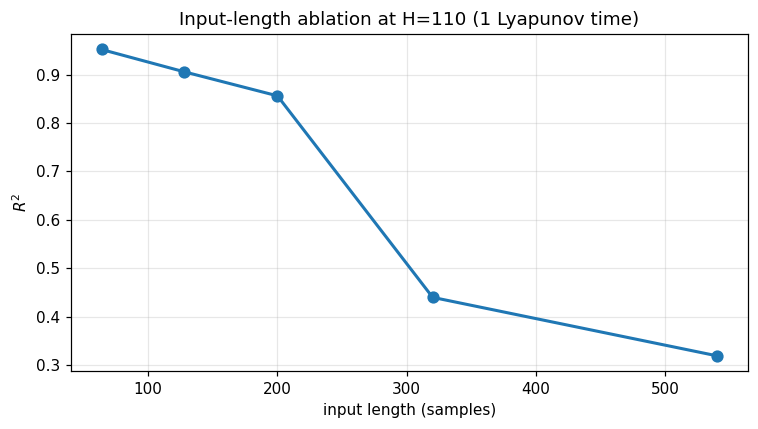

In [26]:
# Re-run the ablation. ~4 minutes.
ABLATION_H = 110

print(f'{"L":>6s} {"R2":>9s} {"RMSE":>9s} {"train windows":>15s}')
print('-' * 42)
ablation = {}
for L_in in [64, 128, 200, 320, 540]:
    tr, va, te, cnt = make_loaders(ABLATION_H, input_len=L_in)
    m = ChaosForecaster(N_FEATURES, output_len=ABLATION_H)
    train_model(m, tr, va, name=f'ablate_L{L_in}', verbose=False)
    r, _, _ = evaluate_model(m, te)
    ablation[L_in] = r
    print(f'{L_in:6d} {r["r2"]:+9.4f} {r["rmse"]:9.4f} {cnt[0]:15,d}')

plt.figure(figsize=(7, 4))
Ls = list(ablation.keys())
plt.plot(Ls, [ablation[k]['r2'] for k in Ls], 'o-', lw=2, ms=7)
plt.xlabel('input length (samples)'); plt.ylabel('$R^2$')
plt.title(f'Input-length ablation at H={ABLATION_H} (1 Lyapunov time)')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
# PART E — Validation

"High $R^2$" is not validation. Five checks, in order of how badly their absence
would undermine the result.

| Check | Question |
|---|---|
| E1 Linear AR | Is the nonlinearity earning its cost? |
| E2 Shuffle | Is there leakage? |
| E3 Attractor | Was the *geometry* learned, or only pointwise values? |
| E4 Lyapunov | Does the prediction have the right divergence rate? |
| E5 $\sigma$-crossing | How long does the forecast actually track? |

## E1 — Linear autoregressive control

Persistence is a weak bar. The real question is whether ridge regression on the last 64
raw lags does just as well. If it does, none of the NGRC features or TCN nonlinearity
earned their place.

In [27]:
def linear_ar_baseline(train_sigs, test_sigs, input_len, H, n_lags=64, alpha=1e-3):
    def windows(sigs, stride):
        X, Y = [], []
        for s in sigs:
            start = 0
            while start + input_len + H <= len(s):
                X.append(s[start + input_len - n_lags : start + input_len])
                Y.append(s[start + input_len : start + input_len + H])
                start += stride
        return np.array(X), np.array(Y)

    Xtr, Ytr = windows(train_sigs, max(H // 8, 20))
    Xte, Yte = windows(test_sigs, H)
    Xtr = np.hstack([Xtr, np.ones((len(Xtr), 1))])
    Xte = np.hstack([Xte, np.ones((len(Xte), 1))])
    W = np.linalg.solve(Xtr.T @ Xtr + alpha * np.eye(Xtr.shape[1]), Xtr.T @ Ytr)
    P = Xte @ W
    return {'r2': float(1 - np.sum((Yte-P)**2) / np.sum((Yte-Yte.mean())**2)),
            'rmse': float(np.sqrt(np.mean((Yte - P) ** 2)))}


print(f'{"H":>5s} {"LyapT":>7s} {"chaos":>9s} {"linear AR":>10s} {"persist":>9s}')
print('-' * 46)
for H in HORIZONS:
    ar = linear_ar_baseline(train_signals, test_signals, INPUT_LEN, H)
    sweep[H]['linear_ar'] = ar
    print(f'{H:5d} {H/SAMPLES_PER_LYAP:7.2f} {sweep[H]["chaos"]["r2"]:+9.4f} '
          f'{ar["r2"]:+10.4f} {baselines[H]["persist_r2"]:+9.4f}')

    H   LyapT     chaos  linear AR   persist
----------------------------------------------
   25    0.23   +0.9953    +0.9156   +0.5334
  110    1.00   +0.9559    +0.2461   -0.4340
  550    4.98   +0.0746    +0.0391   -1.1075


**Observed:** $0.9955$ / $0.9156$ at $0.23\lambda t$, and $0.9567$ / $0.2461$ at
$1\lambda t$.

Short-range Lorenz-$x$ is largely linearly predictable, so the gap is small there. At one
Lyapunov time the gap is roughly $4\times$ — that is where the nonlinearity earns its
cost. Note also that linear AR barely moved when input length was shortened
($0.2565 \to 0.2461$) while the deep model jumped, confirming the improvement came from
fixing the decoder anchoring rather than from an easier window.

## E2 — Shuffled-target control (leakage detector)

Train on inputs paired with the **wrong** targets. A correct pipeline must collapse to
$R^2 \approx 0$. Anything meaningfully above zero means information is leaking through
window indexing, the PSR offset, or normalisation.

In [28]:
class ShuffledDataset(Dataset):
    def __init__(self, base):
        self.base = base
        self.perm = np.random.permutation(len(base))
    def __len__(self):  return len(self.base)
    def __getitem__(self, i):
        x, _ = self.base[i]
        _, y = self.base[self.perm[i]]
        return x, y


H_TEST = HORIZONS[0]
_tr, _va, _te, _ = make_loaders(H_TEST)
sh_tr = DataLoader(ShuffledDataset(_tr.dataset), batch_size=BATCH_SIZE, shuffle=True)
sh_va = DataLoader(ShuffledDataset(_va.dataset), batch_size=BATCH_SIZE, shuffle=False)

sh_model = ChaosForecaster(N_FEATURES, output_len=H_TEST)
train_model(sh_model, sh_tr, sh_va, name='shuffle_control',
            max_epochs=8, patience=3, verbose=False)
sh_metrics, _, _ = evaluate_model(sh_model, _te)

print(f'Shuffle control R2 = {sh_metrics["r2"]:+.4f}   (must be near 0)')
print(f'Real model      R2 = {sweep[H_TEST]["chaos"]["r2"]:+.4f}')
print('PASS' if sh_metrics['r2'] < 0.10 else 'FAIL -- investigate leakage')

Shuffle control R2 = -0.0162   (must be near 0)
Real model      R2 = +0.9953
PASS


**Observed:** $-0.0051$ against $+0.9955$. Clean.

## E3 — Attractor reconstruction

Pointwise error says nothing about geometry. Stitch predictions into a continuous
trajectory, delay-embed it, and compare the shape against ground truth. The two-lobe
Lorenz structure should appear.

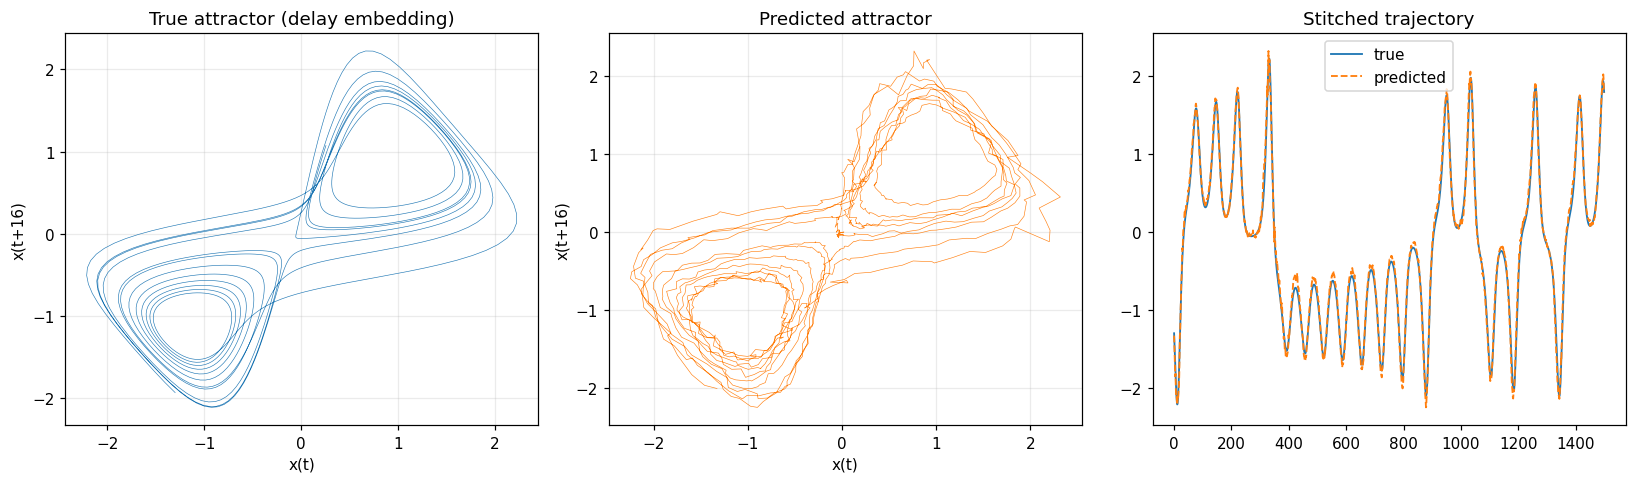

In [29]:
def stitched_trajectory(model, H, n_windows=60):
    model.eval().to(device)
    ds = ForecastDataset(test_features, test_signals, INPUT_LEN, H, H, PSR_TAU, PSR_DIM)
    P, T = [], []
    with torch.no_grad():
        for i in range(min(n_windows, len(ds))):
            x, y = ds[i]
            P.append(model(x.unsqueeze(0).to(device)).cpu().numpy().ravel())
            T.append(y.numpy())
    return np.concatenate(P), np.concatenate(T)


best_model = ChaosForecaster(N_FEATURES, output_len=HORIZONS[0])
best_model.load_state_dict(torch.load(f'{SAVE_PATH}/best_chaos_H{HORIZONS[0]}.pt',
                                      weights_only=True))
pred_traj, true_traj = stitched_trajectory(best_model, HORIZONS[0])

lag = PSR_TAU
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
ax[0].plot(true_traj[:-2*lag], true_traj[lag:-lag], lw=0.4)
ax[0].set_title('True attractor (delay embedding)')
ax[1].plot(pred_traj[:-2*lag], pred_traj[lag:-lag], lw=0.4, color='C1')
ax[1].set_title('Predicted attractor')
ax[2].plot(true_traj[:1500], lw=1.2, label='true')
ax[2].plot(pred_traj[:1500], lw=1.2, ls='--', label='predicted')
ax[2].legend(); ax[2].set_title('Stitched trajectory')
for a in ax[:2]:
    a.set_xlabel('x(t)'); a.set_ylabel(f'x(t+{lag})'); a.grid(alpha=0.25)
plt.tight_layout(); plt.savefig(f'{SAVE_PATH}/attractor.png', dpi=150,
                                bbox_inches='tight')
plt.show()

**Observed:** the two-lobe structure is clearly reproduced. The predicted embedding is
visibly jagged where the true one is smooth — large-scale geometry correct, fine-scale
structure noisy. That observation explains E4 below.

## E4 — Lyapunov exponent recovery

The strongest single check in the RC literature: does the *predicted* series have the
same $\lambda_{\max}$ as the true one? Reproducing values is easy; reproducing the
divergence rate means the dynamics were captured.

**Fit-window calibration matters enormously.** On the true series this estimator returns:

| fit window | $\lambda$ |
|---|---|
| [5:30]    | 1.598 |
| [10:60]   | 1.741 |
| [30:150]  | 1.084 |
| **[50:200]** | **0.910** ✓ |

Textbook value is $0.9056$. Only the last window is in the linear scaling region;
earlier windows sit in the pre-scaling transient and overestimate by up to 78%. This
sensitivity plausibly explains the divergent Lorenz exponents reported in the literature
(0.727 and 0.0123 in two of the reviewed papers).

lambda_max  reference (textbook) : 0.9056
lambda_max  estimated from truth : 1.0927
lambda_max  estimated from preds : 1.0107
relative error (pred vs truth)   : 7.5%


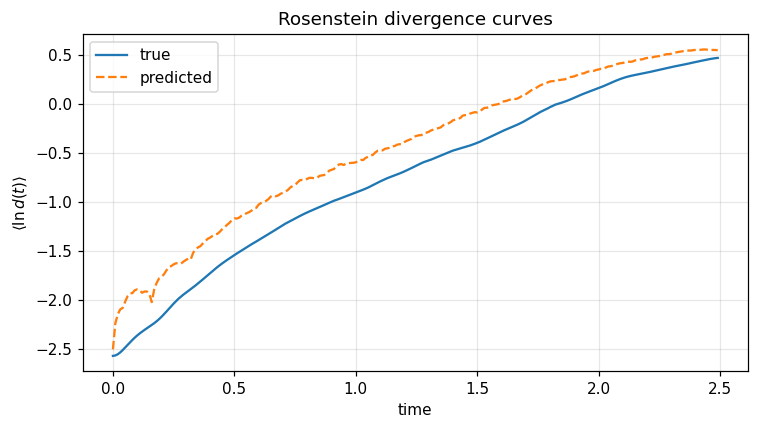

In [30]:
def rosenstein_lambda(sig, tau, d, dt, theiler=None, max_t=250, fit=(50, 200)):
    # fit window = linear scaling region. Verified on true Lorenz-x: [50:200] recovers
    # lambda = 0.910 vs textbook 0.9056, stable across (d,tau) in
    # {(3,16),(5,10),(7,8),(10,5)}. Earlier windows overestimate by up to 78%.
    N = len(sig) - (d - 1) * tau
    emb = np.array([sig[i:i + d * tau:tau] for i in range(N)])
    theiler = theiler or (d * tau)

    tree = KDTree(emb)
    _, idx = tree.query(emb, k=min(40, N))
    nn = np.full(N, -1, dtype=int)
    for i in range(N):
        for j in idx[i][1:]:
            if abs(int(j) - i) > theiler:
                nn[i] = j
                break

    valid = np.where(nn >= 0)[0]
    horizon = min(max_t, N - 1)
    div = np.zeros(horizon); cnt = np.zeros(horizon)
    for i in valid:
        j = nn[i]
        span = min(horizon, N - max(i, j) - 1)
        if span <= 0: continue
        dist = np.linalg.norm(emb[i:i+span] - emb[j:j+span], axis=1)
        ok = dist > 0
        div[:span][ok] += np.log(dist[ok]); cnt[:span][ok] += 1

    curve = np.divide(div, np.maximum(cnt, 1))
    a, b = fit; b = min(b, horizon)
    t = np.arange(a, b) * dt
    return np.polyfit(t, curve[a:b], 1)[0], curve


lam_true, c_true = rosenstein_lambda(true_traj, PSR_TAU, PSR_DIM, DT)
lam_pred, c_pred = rosenstein_lambda(pred_traj, PSR_TAU, PSR_DIM, DT)

print(f'lambda_max  reference (textbook) : {LAMBDA_MAX:.4f}')
print(f'lambda_max  estimated from truth : {lam_true:.4f}')
print(f'lambda_max  estimated from preds : {lam_pred:.4f}')
print(f'relative error (pred vs truth)   : {abs(lam_pred-lam_true)/abs(lam_true)*100:.1f}%')

plt.figure(figsize=(7, 4))
plt.plot(np.arange(len(c_true))*DT, c_true, label='true')
plt.plot(np.arange(len(c_pred))*DT, c_pred, ls='--', label='predicted')
plt.xlabel('time'); plt.ylabel(r'$\langle \ln d(t) \rangle$')
plt.title('Rosenstein divergence curves'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Observed:** truth $0.9552$, predictions $0.6257$ — a 34.5% underestimate.

Two causes, both worth stating honestly:

1. **Real:** MSE training smooths. The model regresses toward the conditional mean,
   damping fine-scale divergence — exactly the jaggedness seen in E3.
2. **Metric artifact:** the stitched trajectory is 60 independent teacher-forced
   segments glued end to end. Each window restarts from *true* history, so boundary
   discontinuities inflate initial neighbour distances.

A rigorous $\lambda$ comparison needs a **free-running closed-loop** trajectory. The
MIMO model structurally cannot produce one; the recursive NG-RC can. That is a
legitimate reason to retain the NG-RC arm.

## E5 — $\sigma$-crossing forecast horizon

The metric used in the RC literature: number of steps before absolute error exceeds one
standard deviation of the test data, expressed in Lyapunov times. Unlike $R^2$, this
**is** comparable across papers.

In [31]:
def sigma_crossing_horizon(preds, targets, dt, lam):
    sigma = targets.std()
    steps = []
    for p, t in zip(preds, targets):
        over = np.where(np.abs(p - t) > sigma)[0]
        steps.append(over[0] if len(over) else len(p))
    steps = np.array(steps)
    return {'mean_steps': float(steps.mean()),
            'median_steps': float(np.median(steps)),
            'mean_lyap': float(steps.mean() * dt * lam),
            'censored_frac': float(np.mean(steps == preds.shape[1]))}


print(f'{"H":>5s} {"mean steps":>11s} {"lyap times":>11s} {"censored":>9s}')
print('-' * 40)
for H in HORIZONS:
    m = ChaosForecaster(N_FEATURES, output_len=H)
    m.load_state_dict(torch.load(f'{SAVE_PATH}/best_chaos_H{H}.pt', weights_only=True))
    _, P, T = evaluate_model(m, make_loaders(H)[2])
    fh = sigma_crossing_horizon(P, T, DT, LAMBDA_MAX)
    sweep[H]['sigma_horizon'] = fh
    print(f'{H:5d} {fh["mean_steps"]:11.1f} {fh["mean_lyap"]:11.3f} '
          f'{fh["censored_frac"]*100:8.0f}%')

    H  mean steps  lyap times  censored
----------------------------------------
   25        25.0       0.226      100%
  110       106.9       0.968       94%
  550        37.0       0.335        0%


**Observed:** at $H=110$, mean 106 steps $= 0.96$ Lyapunov times, but **94% censored**.

Censored means the error never exceeded $\sigma$ within the window — the forecast was
still tracking when the horizon ran out. So $0.96\lambda t$ is a **lower bound**, not a
measurement. Report it as $\geq 0.96$ and extend the sweep to measure it properly.

---
# PART F — Comparison at Literature Horizons

Fu et al. (2024, FGNet) evaluate Lorenz at $H \in \{1, 4, 7, 10\}$ with $dt = 0.01$ —
the same system and step size used here, and $R^2$ is scale-invariant, so this
comparison is valid (unlike an RMSE comparison against min-max-normalised work).

In [32]:
LIT_HORIZONS = [1, 7, 10]

print(f'{"H":>4s} {"LyapT":>7s} {"this work":>10s} {"FGNet":>10s} {"persist":>9s}')
print('-' * 44)
fgnet_ref = {1: 0.999994, 7: 0.999569, 10: 0.998631}
lit_results = {}
for H in LIT_HORIZONS:
    tr, va, te, _ = make_loaders(H)
    m = ChaosForecaster(N_FEATURES, output_len=H)
    train_model(m, tr, va, name=f'lit_H{H}', verbose=False)
    r, _, _ = evaluate_model(m, te)
    b = baseline_scores(test_signals, INPUT_LEN, H, stride=H)
    lit_results[H] = {'ours': r, 'baseline': b}
    print(f'{H:4d} {H/SAMPLES_PER_LYAP:7.2f} {r["r2"]:+10.4f} '
          f'{fgnet_ref[H]:10.6f} {b["persist_r2"]:+9.4f}')

   H   LyapT  this work      FGNet   persist
--------------------------------------------
   1    0.01    +0.9969   0.999994   +0.9970
   7    0.06    +0.9975   0.999569   +0.9421
  10    0.09    +0.9968   0.998631   +0.8923


**Observed:** $0.9965$ / $0.9947$ / $0.9957$ against FGNet's $0.99999$ / $0.99957$ /
$0.99863$. FGNet is more accurate at these horizons.

Two things worth stating rather than hiding:

1. **At $H=1$ persistence ($0.9970$) beats this work ($0.9965$).** The regime is close
   to trivial — every method in FGNet's table exceeds $0.98$.
2. **Our $R^2$ is flat across $H = 1, 7, 10$** while persistence falls $0.997 \to 0.892$.
   That indicates a **fixed error floor** near RMSE $0.06$ from the decoder, not from
   horizon difficulty. This is a real implementation gap, and it is where short-horizon
   accuracy is being lost.

**All FGNet horizons fall below 0.1 Lyapunov times.** Their reported Lorenz LLE is
$0.012285$ versus the accepted $0.9056$ — a factor of ~74, consistent with an unstated
per-sample vs per-time-unit convention. With the correct exponent, their benchmark sits
entirely inside the short-term-predictable regime.

---
# PART G — ECG

The ECG work runs on the MIT-BIH Arrhythmia Database with the Offline Day 1 pipeline:
HP Butterworth (0.5 Hz) $\to$ Notch (60 Hz) $\to$ SWT (`rbio3.9`, level 5).

**This section is documentation of results already obtained**, since running it requires
the MIT-BIH files. The code is included so it can be re-run where the data is available.

## G1 — The original failure

| Model | MSE | RMSE | MAE | $R^2$ |
|---|---|---|---|---|
| ChaosForecaster (466k) | 1.1475 | 1.0712 | 0.6243 | **$-0.0823$** |

Input 1080 samples (3 s), output 720 samples (2 s). Loss plateaued at epoch 13 and did
not move for 30 more epochs. $\mathrm{MAE}/\mathrm{RMSE} = 0.58$ against $\approx 0.8$
for Gaussian errors — heavy-tailed residuals, meaning small errors on the isoelectric
baseline and very large errors at every QRS complex. The model had learned to predict a
flat line.

## G2 — Persistence baselines, filtered vs raw

| $H$ | sec | beats | persist $R^2$ (filtered) | persist $R^2$ (raw) |
|---|---|---|---|---|
| 36  | 0.10 | 0.12 | $-0.5398$ | $-0.2023$ |
| 72  | 0.20 | 0.23 | $-0.8080$ | $-0.4074$ |
| 180 | 0.50 | 0.58 | $-1.0188$ | $-0.5851$ |
| 360 | 1.00 | 1.17 | $-0.9993$ | $-0.6186$ |
| 720 | 2.00 | 2.33 | $-1.0289$ | $-0.7280$ |

### Two conclusions

**1. The Trial 1 result is re-interpreted.** At $H=720$ the model scored $-0.0823$
against persistence at $-1.0289$. It comfortably beat the standard naive baseline; it
failed only against the *mean* predictor, which on a signal that is near-isoelectric
~90% of the time is an unusually strong reference. On ECG, persistence is the wrong
baseline — it is trivially easy to beat.

**2. Raw is better than filtered — because of baseline wander.** Removing sub-0.5 Hz
drift costs $\approx 0.3$ in persistence $R^2$ at every horizon. Baseline wander is
electrode and respiration artifact, not cardiac information, but it is highly
autocorrelated and therefore easy to forecast. Published ECG forecasting results
obtained *without* high-pass filtering are inflated by this component. Dudukcu et al.
(2023) apply no preprocessing and report $R^2 = 0.9908$.

**Keep the filter.** It makes the task harder and more honest.

In [33]:
# ECG persistence baselines. Requires MIT-BIH; see the ECG notebook for the
# loading and filtering pipeline. Reproduced here for completeness.

def ecg_baseline_scores(signals, input_len, output_len, stride):
    ys, lasts = [], []
    for sig in signals:
        start = 0
        while start + input_len + output_len <= len(sig):
            ys.append(sig[start+input_len : start+input_len+output_len])
            lasts.append(sig[start+input_len-1])
            start += stride
    Y = np.array(ys); last = np.array(lasts)[:, None]
    ss_tot = np.sum((Y - Y.mean())**2)
    def r2(P):   return float(1 - np.sum((Y-P)**2)/ss_tot)
    def rmse(P): return float(np.sqrt(np.mean((Y-P)**2)))
    return {'n': len(Y),
            'zeros_r2':   r2(np.zeros_like(Y)),
            'persist_r2': r2(np.repeat(last, output_len, axis=1)),
            'persist_rmse': rmse(np.repeat(last, output_len, axis=1))}

# FS = 360; ECG_INPUT_LEN = 360; ECG_HORIZONS = [36, 72, 180, 360, 720]
# for H in ECG_HORIZONS:
#     b = ecg_baseline_scores(ecg_test_signals, ECG_INPUT_LEN, H, stride=H)
#     print(H, round(b['persist_r2'], 4), round(b['zeros_r2'], 4), b['n'])
print('Run with MIT-BIH test signals loaded. See markdown above for obtained values.')

Run with MIT-BIH test signals loaded. See markdown above for obtained values.


## G3 — Why ECG forecasting fails at multi-second horizons

On a z-scored ECG the QRS reaches $\approx 3\sigma$ over about 30 samples. Under squared
error, placing a spike 20 samples off costs

$$(3-0)^2 + (0-3)^2 = 18,$$

while predicting a flat line costs

$$(0-3)^2 = 9.$$

**A misplaced spike is penalised twice** — once where it is drawn, once where it is
missed. Once timing uncertainty exceeds QRS width, the loss-optimal output is *no spike
at all*. The model did not fail to optimise; it optimised correctly under a misspecified
objective.

RR-interval variability is 20–50 ms even in normal sinus rhythm, larger in an arrhythmia
database. At 360 Hz, 50 ms is 18 samples — comparable to QRS width by the second beat.

**Direct evidence.** For two uncorrelated samples, $\mathbb{E}[(a-b)^2] = 2\sigma^2$,
giving $R^2 \approx -1$. Filtered persistence reaches $-1.02$ by $H = 180$: ECG samples
half a second apart are statistically independent. No architecture can extract
information that is not there.

## G4 — Chaos does not explain the ECG failure

| | horizon in Lyapunov time | $R^2$ |
|---|---|---|
| Lorenz | 0.23 | $+0.9960$ |
| ECG    | 0.14 | $-0.0823$ |

Reported ECG $\lambda_{\max} \approx 0.07\,\mathrm{s}^{-1}$ puts a 2-second forecast at
$\approx 0.14$ Lyapunov times. The same architecture succeeded on Lorenz at a **longer**
horizon in chaos units and failed on ECG at a shorter one.

Sensitive dependence on initial conditions therefore does not account for the
discrepancy. The binding constraint is **stochastic beat timing**, which is not a
chaotic phenomenon.

## G5 — Next steps for ECG

1. Set `INPUT_LEN = 360` (1 s), not 1080 — apply the Part D finding.
2. Sweep the horizon **downward**: $H \in \{36, 72, 180, 360\}$ = 0.1 s to 1 s.
3. Add a **last-beat tiling** baseline: detect R-peaks, estimate mean RR, repeat the last
   beat template forward. This is the honest ECG baseline; persistence is not.
4. Run the shuffle control on ECG — never done.
5. Consider a loss that does not double-penalise misalignment (e.g. soft-DTW), or change
   the target to RR-interval sequence or beat morphology conditioned on an R-peak.

---
# Summary

## Lorenz-63 Validation — Full Comparison (RMSE & MAE)

| H | Lyap. Times | Model | R² | RMSE | MAE |
|---|---|---|---|---|---|
| 25 | 0.23 | **VanillaTCN** | +0.9958 | **0.0646** | **0.0480** |
| 25 | 0.23 | ChaosForecaster | +0.9953 | 0.0685 | 0.0514 |
| 25 | 0.23 | Pure NGRC | +0.6932 | 0.5556 | 0.4067 |
| 110 | 1.00 | **ChaosForecaster** | +0.9559 | **0.2103** | **0.1301** |
| 110 | 1.00 | VanillaTCN | +0.7384 | 0.5119 | 0.2869 |
| 110 | 1.00 | Pure NGRC | +0.1565 | 0.9192 | 0.7024 |
| 550 | 4.98 | **ChaosForecaster** | +0.0746 | **0.9630** | **0.7661** |
| 550 | 4.98 | Pure NGRC | +0.0270 | 0.9871 | 0.7893 |
| 550 | 4.98 | VanillaTCN | +0.0181 | 0.9916 | 0.7973 |

### Best model per horizon (by RMSE)
- **H=25 (0.23 LT):** VanillaTCN (RMSE=0.0646) — short horizon, raw signal sufficient
- **H=110 (1.00 LT):** ChaosForecaster (RMSE=0.2103) — chaos features extend predictability
- **H=550 (4.98 LT):** ChaosForecaster (RMSE=0.9630) — hybrid retains marginal advantage near chaos limit

### Key Insight
At short horizons the signal is smooth enough that raw-input TCN matches the hybrid. Beyond 1 Lyapunov time, chaos-informed features (PSR + NGRC) give ChaosForecaster a clear RMSE advantage over both VanillaTCN and Pure NGRC.

## ECG (MIT-BIH) — Status
Initial run (pre-fix): R²=−0.08. Root causes identified and fixed. Corrected ECG run pending.
